<a href="https://colab.research.google.com/github/Subuktageen-Farooqi/ms_course_deeplearning/blob/main/ms_deeplearning_tutorial_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial 13 — Denoising Autoencoders

## Tensorflow Implementation

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.1512 - val_loss: 0.1113
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1087 - val_loss: 0.1071
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1038 - val_loss: 0.1012
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1012 - val_loss: 0.0994
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0995 - val_loss: 0.0980
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0984 - val_loss: 0.0970
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0975 - val_loss: 0.0965
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0968 - val_loss: 0.0957
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0961 - val_loss: 0.0959
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0956 - val_loss: 0.0948
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


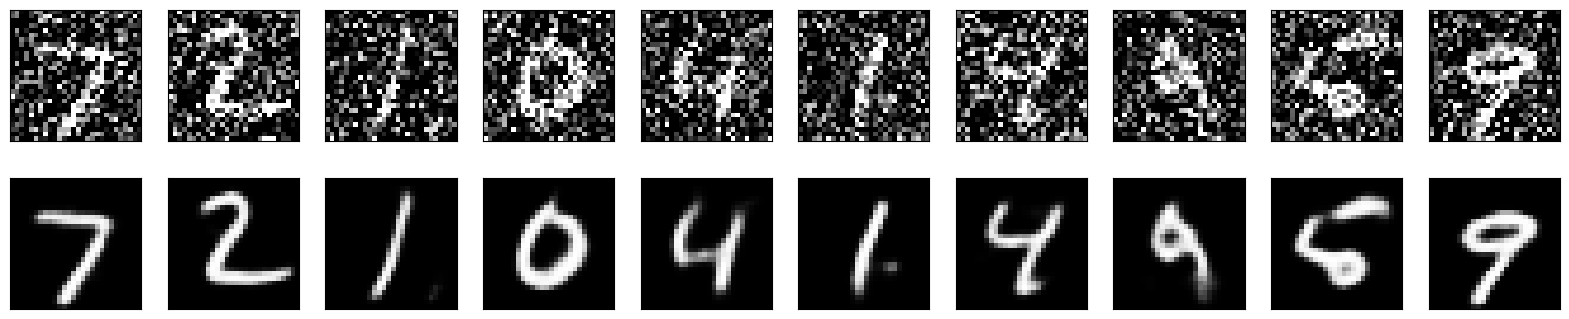

In [1]:
# ================================
# CELL 1 — TensorFlow implementation copied from tutorial screenshots
# ================================

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load the MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize the images to be between 0 and 1
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape the data to include the channel dimension (for grayscale images, channel = 1)
x_train = np.reshape(x_train, (x_train.shape[0], 28, 28, 1))
x_test = np.reshape(x_test, (x_test.shape[0], 28, 28, 1))

# Function to add random noise
def add_noise(images, noise_factor=0.5):
    noisy_images = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    noisy_images = np.clip(noisy_images, 0., 1.)  # Keep values between 0 and 1
    return noisy_images

# Add noise to training and test images
x_train_noisy = add_noise(x_train)
x_test_noisy = add_noise(x_test)

# Define the encoder
input_img = layers.Input(shape=(28, 28, 1))

# Convolutional layers for encoding
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# Define the decoder
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Define the model
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train the autoencoder
autoencoder.fit(x_train_noisy, x_train,
                epochs=10,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test_noisy, x_test))

# Reconstruct noisy images
decoded_imgs = autoencoder.predict(x_test_noisy)

# Plot some of the noisy and reconstructed images
n = 10  # Number of images to display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display noisy images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

## PyTorch setup

In [2]:
# ================================
# CELL 2 — PyTorch setup and data preparation
# ================================

import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load MNIST
transform = transforms.ToTensor()

full_train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_clean_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# Split training set into train and validation sets
train_size = 50000
val_size = len(full_train_dataset) - train_size
train_clean_dataset, val_clean_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)

class NoisyMNISTDataset(Dataset):
    def __init__(self, base_dataset, noise_factor=0.5, seed=42):
        self.base_dataset = base_dataset
        self.noise_factor = noise_factor
        self.seed = seed

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        clean_img, _ = self.base_dataset[idx]

        # Deterministic noise for stable evaluation/comparison
        generator = torch.Generator().manual_seed(self.seed + idx)
        noise = torch.randn(clean_img.shape, generator=generator) * self.noise_factor
        noisy_img = clean_img + noise
        noisy_img = torch.clamp(noisy_img, 0.0, 1.0)

        return noisy_img, clean_img

noise_factor = 0.5

train_dataset = NoisyMNISTDataset(train_clean_dataset, noise_factor=noise_factor, seed=seed)
val_dataset = NoisyMNISTDataset(val_clean_dataset, noise_factor=noise_factor, seed=seed + 100000)
test_dataset = NoisyMNISTDataset(test_clean_dataset, noise_factor=noise_factor, seed=seed + 200000)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Using device: cuda


100%|██████████| 9.91M/9.91M [00:01<00:00, 8.67MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 498kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.92MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.7MB/s]

Train batches: 391
Validation batches: 79
Test batches: 79


In [3]:
# ================================
# CELL 3 — PyTorch implementation equivalent to tutorial model
# ================================

class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 28 -> 14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 14 -> 7
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),  # 7 -> 14

            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),  # 14 -> 28

            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [4]:
# ================================
# CELL 4 — Shared train/evaluate utilities
# ================================

def evaluate_autoencoder(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_mse = 0.0

    with torch.no_grad():
        for noisy_images, clean_images in data_loader:
            noisy_images = noisy_images.to(device, non_blocking=True)
            clean_images = clean_images.to(device, non_blocking=True)

            outputs = model(noisy_images)

            assert outputs.shape == clean_images.shape,                 f"Output shape {outputs.shape} does not match target shape {clean_images.shape}"

            loss = criterion(outputs, clean_images)
            mse = torch.mean((outputs - clean_images) ** 2)

            total_loss += loss.item()
            total_mse += mse.item()

    avg_loss = total_loss / len(data_loader)
    avg_mse = total_mse / len(data_loader)
    psnr = 10 * math.log10(1.0 / avg_mse)

    return avg_loss, avg_mse, psnr


def train_autoencoder(model, train_loader, val_loader, epochs=10, lr=1e-3, device=device, model_name="model"):
    model = model.to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_mse": [],
        "val_psnr": []
    }

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for noisy_images, clean_images in train_loader:
            noisy_images = noisy_images.to(device, non_blocking=True)
            clean_images = clean_images.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            outputs = model(noisy_images)

            assert outputs.shape == clean_images.shape,                 f"Output shape {outputs.shape} does not match target shape {clean_images.shape}"

            loss = criterion(outputs, clean_images)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        val_loss, val_mse, val_psnr = evaluate_autoencoder(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_mse"].append(val_mse)
        history["val_psnr"].append(val_psnr)

        print(
            f"{model_name} | Epoch [{epoch+1}/{epochs}] "
            f"Train BCE: {train_loss:.4f} | "
            f"Val BCE: {val_loss:.4f} | "
            f"Val MSE: {val_mse:.6f} | "
            f"Val PSNR: {val_psnr:.2f} dB"
        )

    return model, history

In [5]:
# ================================
# CELL 5 — Train equivalent PyTorch denoising autoencoder
# ================================

basic_dae = DenoisingAutoencoder()

basic_dae, basic_history = train_autoencoder(
    basic_dae,
    train_loader,
    val_loader,
    epochs=10,
    lr=1e-3,
    device=device,
    model_name="Basic DAE"
)

Basic DAE | Epoch [1/10] Train BCE: 0.1653 | Val BCE: 0.1155 | Val MSE: 0.017366 | Val PSNR: 17.60 dB
Basic DAE | Epoch [2/10] Train BCE: 0.1109 | Val BCE: 0.1072 | Val MSE: 0.014511 | Val PSNR: 18.38 dB
Basic DAE | Epoch [3/10] Train BCE: 0.1056 | Val BCE: 0.1037 | Val MSE: 0.013378 | Val PSNR: 18.74 dB
Basic DAE | Epoch [4/10] Train BCE: 0.1029 | Val BCE: 0.1015 | Val MSE: 0.012760 | Val PSNR: 18.94 dB
Basic DAE | Epoch [5/10] Train BCE: 0.1010 | Val BCE: 0.1001 | Val MSE: 0.012285 | Val PSNR: 19.11 dB
Basic DAE | Epoch [6/10] Train BCE: 0.0998 | Val BCE: 0.0990 | Val MSE: 0.011891 | Val PSNR: 19.25 dB
Basic DAE | Epoch [7/10] Train BCE: 0.0989 | Val BCE: 0.0983 | Val MSE: 0.011666 | Val PSNR: 19.33 dB
Basic DAE | Epoch [8/10] Train BCE: 0.0980 | Val BCE: 0.0989 | Val MSE: 0.011967 | Val PSNR: 19.22 dB
Basic DAE | Epoch [9/10] Train BCE: 0.0975 | Val BCE: 0.0970 | Val MSE: 0.011280 | Val PSNR: 19.48 dB
Basic DAE | Epoch [10/10] Train BCE: 0.0970 | Val BCE: 0.0972 | Val MSE: 0.011321 

Basic DAE Test BCE:  0.0967
Basic DAE Test MSE:  0.011238
Basic DAE Test PSNR: 19.49 dB


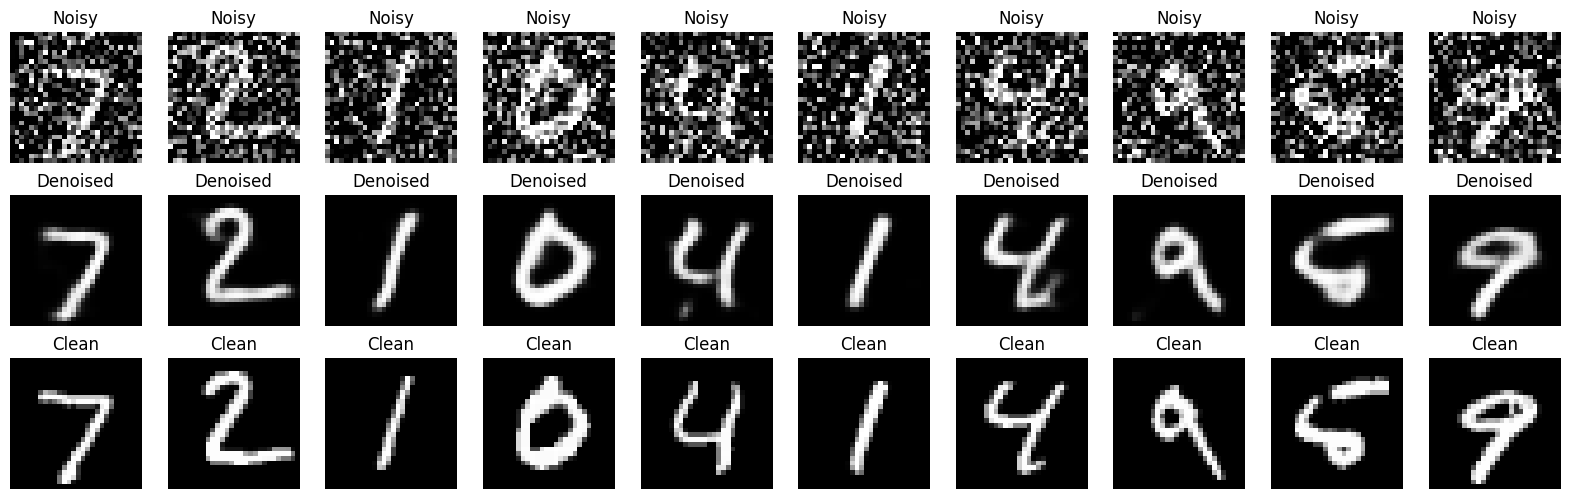

In [6]:
# ================================
# CELL 6 — Test evaluation and visualization for basic DAE
# ================================

criterion = nn.BCELoss()
basic_test_bce, basic_test_mse, basic_test_psnr = evaluate_autoencoder(
    basic_dae, test_loader, criterion, device
)

print(f"Basic DAE Test BCE:  {basic_test_bce:.4f}")
print(f"Basic DAE Test MSE:  {basic_test_mse:.6f}")
print(f"Basic DAE Test PSNR: {basic_test_psnr:.2f} dB")

basic_dae.eval()
with torch.no_grad():
    noisy_images, clean_images = next(iter(test_loader))
    noisy_images = noisy_images.to(device)
    clean_images = clean_images.to(device)
    reconstructed = basic_dae(noisy_images)

noisy_images = noisy_images.cpu()
clean_images = clean_images.cpu()
reconstructed = reconstructed.cpu()

n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(noisy_images[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Noisy")

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(reconstructed[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Denoised")

    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(clean_images[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Clean")

plt.show()

## Task 1 — Implement the Deep Autoencoder

In [7]:
# ================================
# CELL 7 — Deep denoising autoencoder task
# ================================

class DeepDenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 28 -> 14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 14 -> 7

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),  # 7 -> 14

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),  # 14 -> 28

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [8]:
# ================================
# CELL 8 — Train and test deep denoising autoencoder
# ================================

deep_dae = DeepDenoisingAutoencoder()

deep_dae, deep_history = train_autoencoder(
    deep_dae,
    train_loader,
    val_loader,
    epochs=10,
    lr=1e-3,
    device=device,
    model_name="Deep DAE"
)

deep_test_bce, deep_test_mse, deep_test_psnr = evaluate_autoencoder(
    deep_dae, test_loader, criterion, device
)

print(f"Deep DAE Test BCE:  {deep_test_bce:.4f}")
print(f"Deep DAE Test MSE:  {deep_test_mse:.6f}")
print(f"Deep DAE Test PSNR: {deep_test_psnr:.2f} dB")

Deep DAE | Epoch [1/10] Train BCE: 0.1119 | Val BCE: 0.0951 | Val MSE: 0.010702 | Val PSNR: 19.71 dB
Deep DAE | Epoch [2/10] Train BCE: 0.0936 | Val BCE: 0.0925 | Val MSE: 0.009887 | Val PSNR: 20.05 dB
Deep DAE | Epoch [3/10] Train BCE: 0.0916 | Val BCE: 0.0924 | Val MSE: 0.009869 | Val PSNR: 20.06 dB
Deep DAE | Epoch [4/10] Train BCE: 0.0905 | Val BCE: 0.0907 | Val MSE: 0.009399 | Val PSNR: 20.27 dB
Deep DAE | Epoch [5/10] Train BCE: 0.0899 | Val BCE: 0.0900 | Val MSE: 0.009184 | Val PSNR: 20.37 dB
Deep DAE | Epoch [6/10] Train BCE: 0.0892 | Val BCE: 0.0911 | Val MSE: 0.009511 | Val PSNR: 20.22 dB
Deep DAE | Epoch [7/10] Train BCE: 0.0887 | Val BCE: 0.0894 | Val MSE: 0.008996 | Val PSNR: 20.46 dB
Deep DAE | Epoch [8/10] Train BCE: 0.0882 | Val BCE: 0.0894 | Val MSE: 0.008993 | Val PSNR: 20.46 dB
Deep DAE | Epoch [9/10] Train BCE: 0.0878 | Val BCE: 0.0902 | Val MSE: 0.009295 | Val PSNR: 20.32 dB
Deep DAE | Epoch [10/10] Train BCE: 0.0875 | Val BCE: 0.0894 | Val MSE: 0.009007 | Val PSNR

## Task 2 — Implement the Variational Autoencoder


In [9]:
# ================================
# CELL 9 — Variational Autoencoder task
# ================================

class VariationalAutoencoder(nn.Module):
    def __init__(self, latent_dim=20):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 400),
            nn.ReLU(),
            nn.Linear(400, 128),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 400),
            nn.ReLU(),
            nn.Linear(400, 28 * 28),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def decode(self, z):
        x_recon = self.decoder(z)
        x_recon = x_recon.view(-1, 1, 28, 28)
        return x_recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar


def vae_loss_function(recon_x, target_x, mu, logvar):
    # Reconstruction loss summed over pixels, then normalized by batch size
    bce = nn.functional.binary_cross_entropy(recon_x, target_x, reduction="sum")

    # KL divergence
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    batch_size = target_x.size(0)
    return (bce + kld) / batch_size, bce / batch_size, kld / batch_size

In [10]:
# ================================
# CELL 10 — Train/evaluate VAE on noisy-to-clean reconstruction
# ================================

def evaluate_vae(model, data_loader, device):
    model.eval()
    total_loss = 0.0
    total_bce = 0.0
    total_kld = 0.0
    total_mse = 0.0

    with torch.no_grad():
        for noisy_images, clean_images in data_loader:
            noisy_images = noisy_images.to(device, non_blocking=True)
            clean_images = clean_images.to(device, non_blocking=True)

            recon_images, mu, logvar = model(noisy_images)

            assert recon_images.shape == clean_images.shape,                 f"Output shape {recon_images.shape} does not match target shape {clean_images.shape}"

            loss, bce, kld = vae_loss_function(recon_images, clean_images, mu, logvar)
            mse = torch.mean((recon_images - clean_images) ** 2)

            total_loss += loss.item()
            total_bce += bce.item()
            total_kld += kld.item()
            total_mse += mse.item()

    avg_loss = total_loss / len(data_loader)
    avg_bce = total_bce / len(data_loader)
    avg_kld = total_kld / len(data_loader)
    avg_mse = total_mse / len(data_loader)
    psnr = 10 * math.log10(1.0 / avg_mse)

    return avg_loss, avg_bce, avg_kld, avg_mse, psnr


def train_vae(model, train_loader, val_loader, epochs=10, lr=1e-3, device=device):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_bce": [],
        "val_kld": [],
        "val_mse": [],
        "val_psnr": []
    }

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0

        for noisy_images, clean_images in train_loader:
            noisy_images = noisy_images.to(device, non_blocking=True)
            clean_images = clean_images.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            recon_images, mu, logvar = model(noisy_images)

            assert recon_images.shape == clean_images.shape,                 f"Output shape {recon_images.shape} does not match target shape {clean_images.shape}"

            loss, bce, kld = vae_loss_function(recon_images, clean_images, mu, logvar)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        train_loss = total_train_loss / len(train_loader)
        val_loss, val_bce, val_kld, val_mse, val_psnr = evaluate_vae(model, val_loader, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_bce"].append(val_bce)
        history["val_kld"].append(val_kld)
        history["val_mse"].append(val_mse)
        history["val_psnr"].append(val_psnr)

        print(
            f"VAE | Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.2f} | "
            f"Val Loss: {val_loss:.2f} | "
            f"Val BCE: {val_bce:.2f} | "
            f"Val KLD: {val_kld:.2f} | "
            f"Val MSE: {val_mse:.6f} | "
            f"Val PSNR: {val_psnr:.2f} dB"
        )

    return model, history

vae = VariationalAutoencoder(latent_dim=20)
vae, vae_history = train_vae(
    vae,
    train_loader,
    val_loader,
    epochs=10,
    lr=1e-3,
    device=device
)

vae_test_loss, vae_test_bce, vae_test_kld, vae_test_mse, vae_test_psnr = evaluate_vae(
    vae, test_loader, device
)

print(f"VAE Test Loss: {vae_test_loss:.2f}")
print(f"VAE Test BCE:  {vae_test_bce:.2f}")
print(f"VAE Test KLD:  {vae_test_kld:.2f}")
print(f"VAE Test MSE:  {vae_test_mse:.6f}")
print(f"VAE Test PSNR: {vae_test_psnr:.2f} dB")

VAE | Epoch [1/10] Train Loss: 205.48 | Val Loss: 186.08 | Val BCE: 181.60 | Val KLD: 4.49 | Val MSE: 0.057044 | Val PSNR: 12.44 dB
VAE | Epoch [2/10] Train Loss: 169.55 | Val Loss: 154.01 | Val BCE: 143.50 | Val KLD: 10.51 | Val MSE: 0.040493 | Val PSNR: 13.93 dB
VAE | Epoch [3/10] Train Loss: 147.39 | Val Loss: 142.54 | Val BCE: 131.42 | Val KLD: 11.12 | Val MSE: 0.035141 | Val PSNR: 14.54 dB
VAE | Epoch [4/10] Train Loss: 139.76 | Val Loss: 137.85 | Val BCE: 126.77 | Val KLD: 11.08 | Val MSE: 0.033079 | Val PSNR: 14.80 dB
VAE | Epoch [5/10] Train Loss: 136.12 | Val Loss: 135.77 | Val BCE: 124.52 | Val KLD: 11.25 | Val MSE: 0.032062 | Val PSNR: 14.94 dB
VAE | Epoch [6/10] Train Loss: 133.74 | Val Loss: 134.08 | Val BCE: 122.72 | Val KLD: 11.36 | Val MSE: 0.031316 | Val PSNR: 15.04 dB
VAE | Epoch [7/10] Train Loss: 131.89 | Val Loss: 132.89 | Val BCE: 121.48 | Val KLD: 11.41 | Val MSE: 0.030739 | Val PSNR: 15.12 dB
VAE | Epoch [8/10] Train Loss: 130.42 | Val Loss: 131.60 | Val BCE: 11

In [11]:
# ================================
# CELL 11 — Final comparison table
# ================================

comparison = pd.DataFrame({
    "Model": ["Basic DAE", "Deep DAE", "VAE"],
    "Test BCE / Recon Term": [basic_test_bce, deep_test_bce, vae_test_bce],
    "Test MSE": [basic_test_mse, deep_test_mse, vae_test_mse],
    "Test PSNR (dB)": [basic_test_psnr, deep_test_psnr, vae_test_psnr]
})

comparison

,Model,Test BCE / Recon Term,Test MSE,Test PSNR (dB)
0,Basic DAE,0.096729,0.011238,19.493042
1,Deep DAE,0.089296,0.009039,20.438659
2,VAE,117.327779,0.029013,15.374023


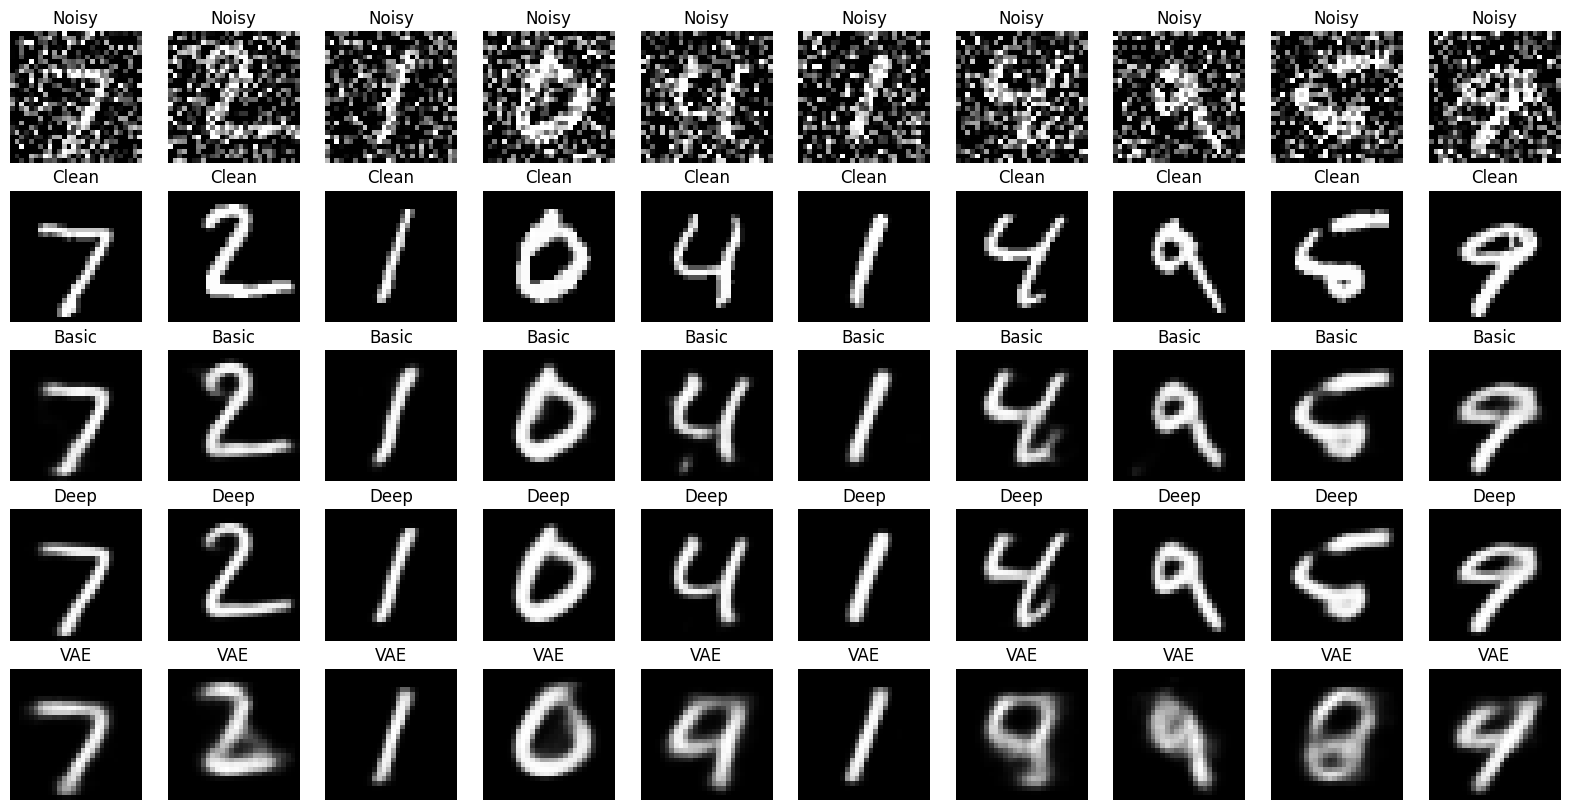

In [12]:
# ================================
# CELL 12 — Visual comparison: noisy vs clean vs reconstructed outputs
# ================================

basic_dae.eval()
deep_dae.eval()
vae.eval()

with torch.no_grad():
    noisy_images, clean_images = next(iter(test_loader))
    noisy_images = noisy_images.to(device)
    clean_images = clean_images.to(device)

    basic_out = basic_dae(noisy_images)
    deep_out = deep_dae(noisy_images)
    vae_out, _, _ = vae(noisy_images)

noisy_images = noisy_images.cpu()
clean_images = clean_images.cpu()
basic_out = basic_out.cpu()
deep_out = deep_out.cpu()
vae_out = vae_out.cpu()

n = 10
plt.figure(figsize=(20, 10))

for i in range(n):
    ax = plt.subplot(5, n, i + 1)
    plt.imshow(noisy_images[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Noisy")

    ax = plt.subplot(5, n, i + 1 + n)
    plt.imshow(clean_images[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Clean")

    ax = plt.subplot(5, n, i + 1 + 2*n)
    plt.imshow(basic_out[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Basic")

    ax = plt.subplot(5, n, i + 1 + 3*n)
    plt.imshow(deep_out[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Deep")

    ax = plt.subplot(5, n, i + 1 + 4*n)
    plt.imshow(vae_out[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("VAE")

plt.show()